# Assignment 2: Transfer Learning Across Two Datasets

**Name:** *(Nati Minota)*

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [3]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: natiminota
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset


100%|██████████| 387M/387M [00:18<00:00, 21.8MB/s]



fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [4]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

In [5]:
import os

fire_dir = os.path.join(data_dir_fire, 'fire_images')
non_fire_dir = os.path.join(data_dir_fire, 'non_fire_images')

num_fire = len(os.listdir(fire_dir))
num_non_fire = len(os.listdir(non_fire_dir))
total_images = num_fire + num_non_fire

print(f"Number of fire images: {num_fire} ({num_fire / total_images:.2%})")
print(f"Number of non-fire images: {num_non_fire} ({num_non_fire / total_images:.2%})")
print(f"Total images: {total_images}")

Number of fire images: 755 (75.58%)
Number of non-fire images: 244 (24.42%)
Total images: 999


there are 755 in the fire class and 244 in the non fire class. when we are spliting the data we have to make sure the split gets equal amount of ratio from each class.

*What did you notice about this dataset? Does it change how you'll approach the next steps?*



## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [6]:
def preprocess(image, label):
    # MobileNetV2 expects inputs normalized in [-1, 1]
    return preprocess_input(image), label

train_fire = train_raw_fire.map(preprocess)
val_fire = val_raw_fire.map(preprocess)
test_fire = test_raw_fire.map(preprocess)

In [7]:
# Load the pretrained MobileNetV2 model without the top classification layer
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

# Create the functional model architecture
inputs = tf.keras.Input(shape=(224, 224, 3))
# Base model call expecting inputs in [-1, 1] (already processed)
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
# Binary classification output (1 unit, sigmoid activation)
outputs = Dense(1, activation='sigmoid')(x)

model_fire = Model(inputs, outputs)
model_fire.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
model_fire.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 1D — Train and Evaluate

In [9]:
history_fire = model_fire.fit(
    train_fire,
    validation_data=val_fire,
    epochs=5
)

Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.8243 - loss: 0.3742 - val_accuracy: 0.9281 - val_loss: 0.2191
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9657 - loss: 0.1496 - val_accuracy: 0.9568 - val_loss: 0.1366
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9743 - loss: 0.1029 - val_accuracy: 0.9640 - val_loss: 0.1010
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9814 - loss: 0.0840 - val_accuracy: 0.9856 - val_loss: 0.0875
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9857 - loss: 0.0725 - val_accuracy: 0.9928 - val_loss: 0.0678


In [10]:
val_loss, val_acc = model_fire.evaluate(val_fire)
test_loss, test_acc = model_fire.evaluate(test_fire)

print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9784 - loss: 0.0874
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.9812 - loss: 0.0802
Validation Accuracy: 0.9784
Test Accuracy: 0.9812


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

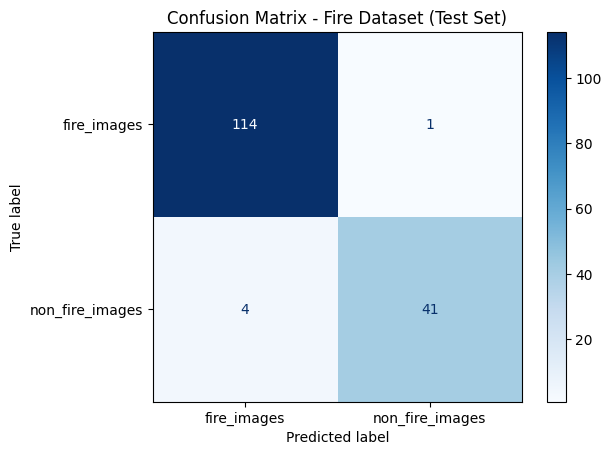

In [11]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Retrieve all true labels and predictions for the test set
y_true = []
y_pred_probs = []

for images, labels in test_fire:
    y_true.extend(labels.numpy())
    preds = model_fire.predict(images, verbose=0)
    y_pred_probs.extend(preds.flatten())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred = (y_pred_probs >= 0.5).astype(int)

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names_fire)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Fire Dataset (Test Set)")
plt.show()

*Your answer:*




A false negative is way worse here because missing an actual fire can lead to a disaster. A false positive is just a false alarm that someone has to check. In real life, I'd lower the decision threshold to something like `0.1` or `0.2`. That way, the model is extra sensitive and flags anything suspicious, even if we get more false alarms. bold text

---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [12]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

['PermanentCrop', 'Highway', 'Industrial', 'River', 'AnnualCrop', 'Pasture', 'HerbaceousVegetation', 'Residential', 'Forest', 'SeaLake']


In [13]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [14]:
def preprocess_sat(image, label):
    # MobileNetV2 expects inputs normalized in [-1, 1]
    return preprocess_input(image), label

train_sat = train_raw_sat.map(preprocess_sat)
val_sat = val_raw_sat.map(preprocess_sat)
test_sat = test_raw_sat.map(preprocess_sat)

In [15]:
# Load the pretrained MobileNetV2 model without the top classification layer
base_model_sat = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model_sat.trainable = False

# Create the functional model architecture for 10-class classification
inputs_sat = tf.keras.Input(shape=(224, 224, 3))
x_sat = base_model_sat(inputs_sat, training=False)
x_sat = GlobalAveragePooling2D()(x_sat)
# 10 units for 10 classes, with softmax activation
outputs_sat = Dense(10, activation='softmax')(x_sat)

model_sat = Model(inputs_sat, outputs_sat)
model_sat.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
model_sat.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 2C — Train and Evaluate

In [17]:
history_sat = model_sat.fit(
    train_sat,
    validation_data=val_sat,
    epochs=5
)

Epoch 1/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 595s 1s/step - accuracy: 0.8777 - loss: 0.3710 - val_accuracy: 0.9294 - val_loss: 0.2185
Epoch 2/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 560s 947ms/step - accuracy: 0.9339 - loss: 0.1945 - val_accuracy: 0.9376 - val_loss: 0.1918
Epoch 3/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 589s 997ms/step - accuracy: 0.9470 - loss: 0.1591 - val_accuracy: 0.9395 - val_loss: 0.1854
Epoch 4/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 593s 1s/step - accuracy: 0.9537 - loss: 0.1379 - val_accuracy: 0.9393 - val_loss: 0.1830
Epoch 5/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 542s 917ms/step - accuracy: 0.9607 - loss: 0.1214 - val_accuracy: 0.9390 - val_loss: 0.1782


In [18]:
val_loss_sat, val_acc_sat = model_sat.evaluate(val_sat)
test_loss_sat, test_acc_sat = model_sat.evaluate(test_sat)

print(f"EuroSAT Validation Accuracy: {val_acc_sat:.4f}")
print(f"EuroSAT Test Accuracy: {test_acc_sat:.4f}")

127/127 ━━━━━━━━━━━━━━━━━━━━ 97s 749ms/step - accuracy: 0.9378 - loss: 0.1818
127/127 ━━━━━━━━━━━━━━━━━━━━ 95s 748ms/step - accuracy: 0.9353 - loss: 0.1808
EuroSAT Validation Accuracy: 0.9378
EuroSAT Test Accuracy: 0.9353


## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

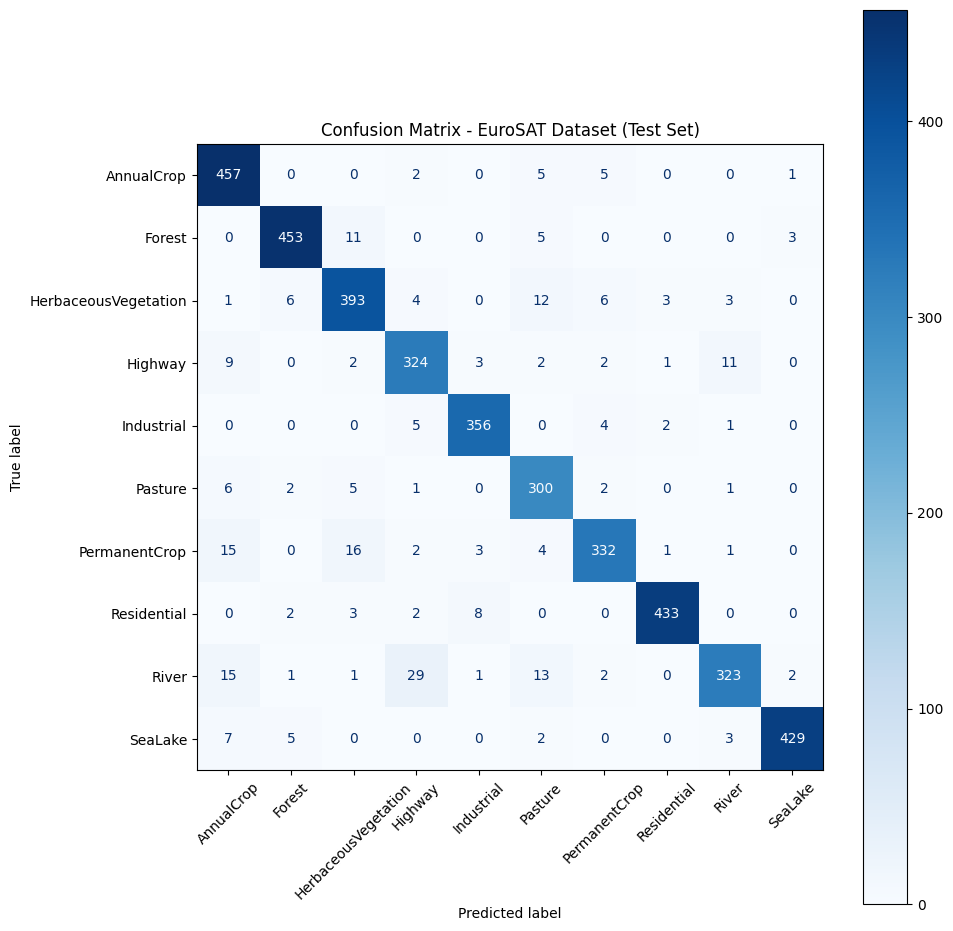

In [22]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Retrieve all true labels and predictions for the EuroSAT test set
y_true_sat = []
y_pred_probs_sat = []

for images, labels in test_sat:
    y_true_sat.extend(labels.numpy())
    preds = model_sat.predict(images, verbose=0)
    y_pred_probs_sat.extend(preds)

y_true_sat = np.array(y_true_sat)
y_pred_probs_sat = np.array(y_pred_probs_sat)
y_pred_sat = np.argmax(y_pred_probs_sat, axis=1)

# Compute the confusion matrix
cm_sat = confusion_matrix(y_true_sat, y_pred_sat)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(10, 10))
disp_sat = ConfusionMatrixDisplay(confusion_matrix=cm_sat, display_labels=class_names_sat)
disp_sat.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix - EuroSAT Dataset (Test Set)")
plt.tight_layout()
plt.show()

*Your answer:* highway and river get confused with each other a lot and because from above they both look long and curvy. so it makes sense.




---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy | .9784| .9378|
| Test Accuracy |.9812 | .9353|

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.
2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

### Part 3 Answers

Fire/Smoke is definitely the closer match to ImageNet. It is just standard, ground level photos which is exactly what ImageNet was trained on, so it got a solid 98.12% test accuracy even with a frozen base. EuroSAT is the big mismatch here. Top down satellite pictures have weird scales and perspectives that look nothing like everyday objects, which is why its test accuracy landed a bit lower at 93.53%.

Fine tuning would definitely help, but it would matter way more for EuroSAT. The model already knows how to find ground level details like smoke and trees for the Fire dataset. But for satellite imagery, it needs to learn entirely new features from a top down view like highway layouts and urban grids. Unfreezing the deeper layers would let those filters adjust to different perspectives.

---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

### Part 4 Reflection

The Fire dataset was pretty unbalanced with way more fire images than non fire images, which meant I had to make sure the data splits kept a similar class ratio so it didn't end up with biased validation or test sets. For the models, Part 1 used a single output unit with a sigmoid activation and binary crossentropy because it was a simple yes/no classification task, while Part 2 needed 10 output units with a softmax activation and sparse categorical crossentropy to handle 10 different land categories. Looking at the results, a pretrained model's usefulness definitely depends on how well its original training matches your target task, not just on how 'good' the architecture is. Since MobileNetV2 was trained on everyday ground level objects, it easily nailed the Fire test set at 98.12% accuracy but struggled more on the unfamiliar top down views of EuroSAT, which only got 93.53% accuracy.